# Phase 8 — Notebook 6: GPT — The Autoregressive Revolution

> **Phase Continuity**: Notebooks 4 and 5 explored the BERT Encoder family — designed for deep *understanding*. This notebook explores the other side of the Transformer coin: the GPT Decoder family, designed for *generation*.

---

## 1. GPT at a Glance

**G**enerative **P**re-trained **T**ransformer — OpenAI, 2018.

Where BERT stacks Transformer **Encoders** with full bidirectional attention, GPT stacks Transformer **Decoders** with **causal (masked) attention**. This seemingly small difference creates a fundamentally different capability: GPT is a natural **text generator**.

```
BERT Encoder Stack:  Token → can attend to ALL surrounding tokens
GPT  Decoder Stack:  Token → can attend ONLY to previous tokens
```

The GPT pre-training objective is deceptively simple: given all preceding tokens, predict the next one. But at web-scale, this forces the model to internalize grammar, facts, reasoning, and style to minimize prediction error.

---

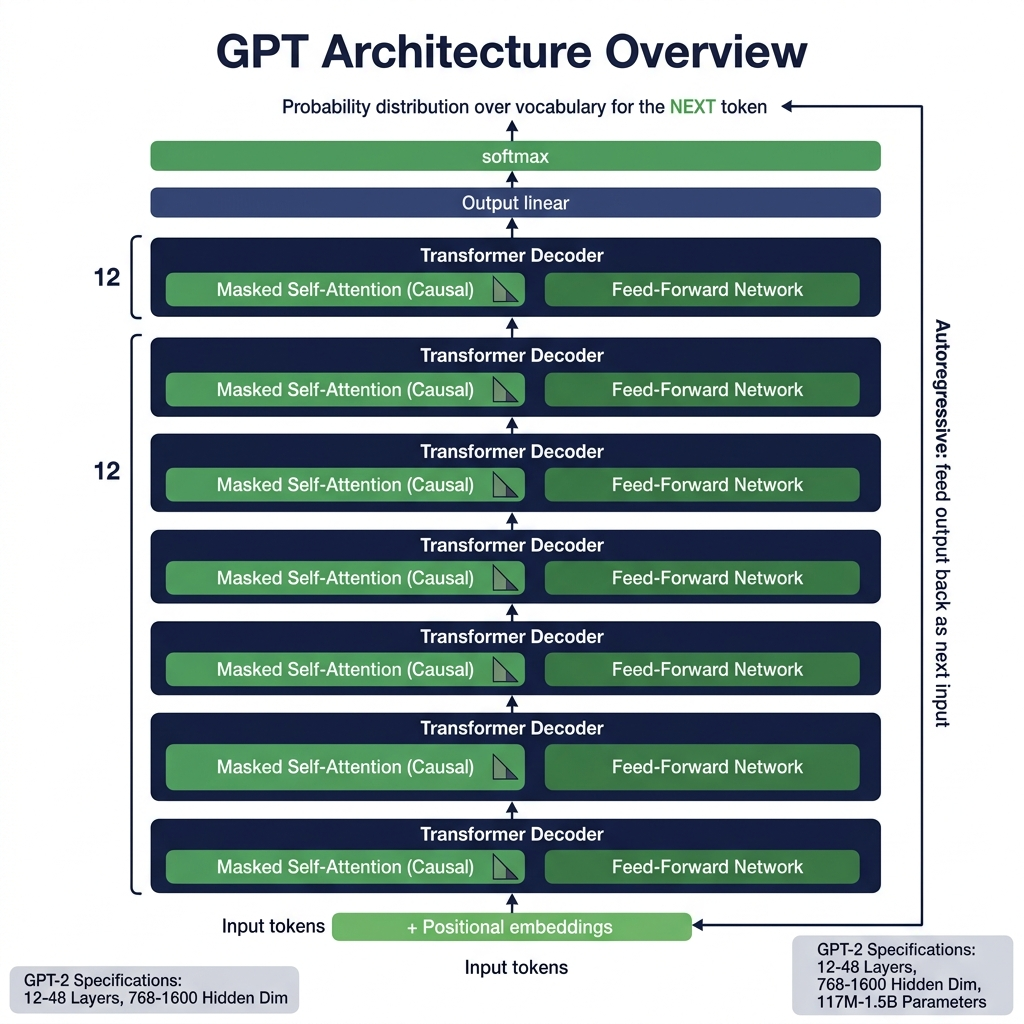

*Figure 1: GPT Architecture — Stacked Transformer Decoder blocks with causal masking and autoregressive generation*



## 2. GPT-1 — The Foundation (2018)

The original GPT paper (Radford et al., 2018) introduced the two-stage paradigm:

### Stage 1: Unsupervised Pre-training
- 12 Transformer Decoder layers, 768 hidden dim, 12 attention heads
- Trained on BookCorpus: **7,000 unpublished books** (~800M words)
- Objective: maximize `P(token_i | token_1, ..., token_{i-1})`

### Stage 2: Supervised Fine-tuning
For each downstream task, GPT-1 added a linear classification layer. The key insight was how to **frame tasks as text sequences** so the same Decoder could handle them all:

| Task | Input Transformation |
|---|---|
| Classification | `[Start] text [Extract]` → label |
| Entailment | `[Start] premise [Delim] hypothesis [Extract]` → label |
| Similarity | `[Start] text1 [Delim] text2 [Extract]` + reverse → combined |
| QA / Comprehension | `[Start] context [Question] q [Answer] a_i [Extract]` per answer |

This task-agnostic input format was a conceptual breakthrough that paved the way for zero-shot prompting.

### GPT-1 Results
GPT-1 achieved new SOTA on 9 of 12 evaluated NLP benchmarks — remarkable for 2018, and all from a single pre-trained model.

---

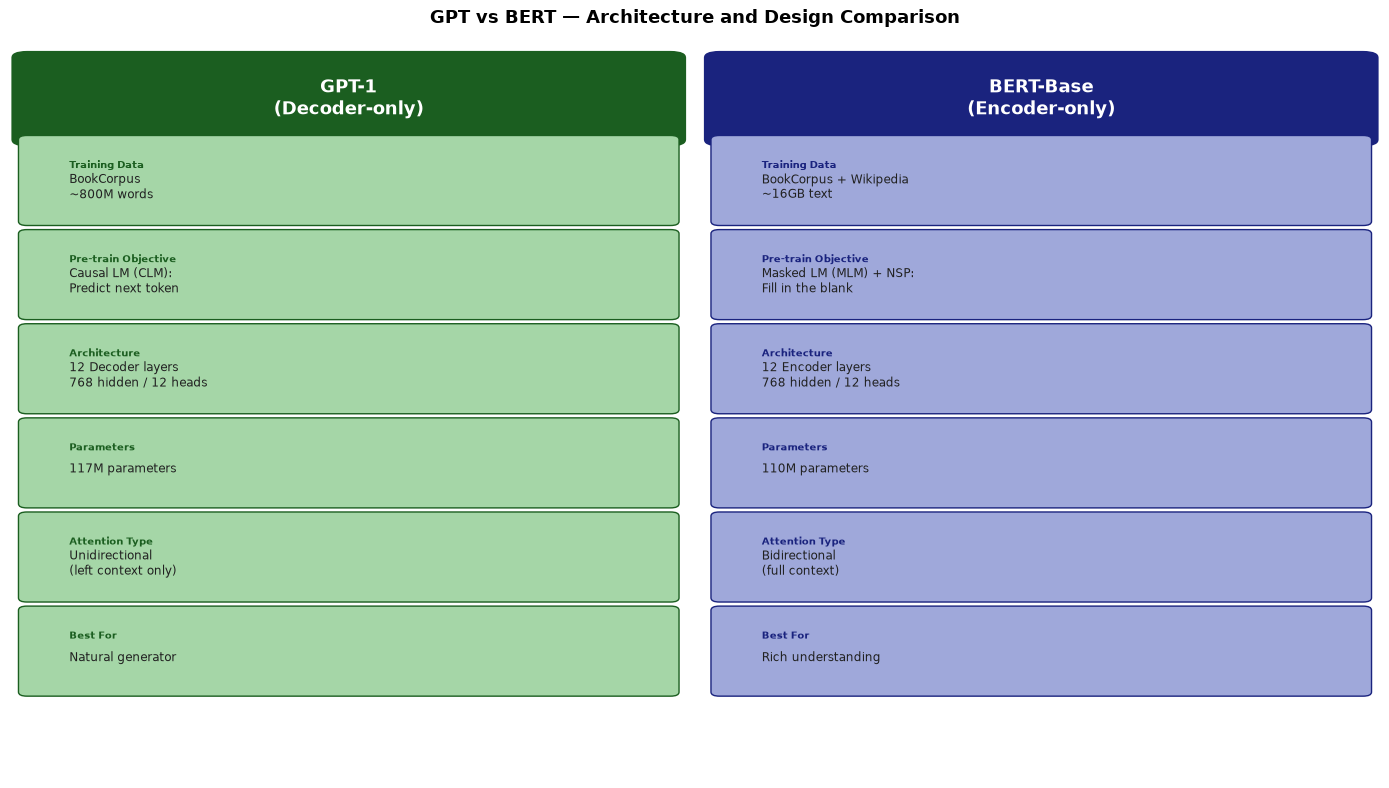

In [1]:
# Visualize GPT-1 vs BERT Architecture comparison
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

models_info = [
    ('GPT-1\n(Decoder-only)', '#1B5E20', '#A5D6A7', [
        'BookCorpus\n~800M words',
        'Causal LM (CLM):\nPredict next token',
        '12 Decoder layers\n768 hidden / 12 heads',
        '117M parameters',
        'Unidirectional\n(left context only)',
        'Natural generator',
    ]),
    ('BERT-Base\n(Encoder-only)', '#1A237E', '#9FA8DA', [
        'BookCorpus + Wikipedia\n~16GB text',
        'Masked LM (MLM) + NSP:\nFill in the blank',
        '12 Encoder layers\n768 hidden / 12 heads',
        '110M parameters',
        'Bidirectional\n(full context)',
        'Rich understanding',
    ]),
]

row_labels = ['Training Data', 'Pre-train Objective', 'Architecture', 'Parameters',
              'Attention Type', 'Best For']
row_icons  = ['[DATA]', '[OBJ]',  '[ARCH]', '[SIZE]', '[ATTN]', '[TASK]']

for ax, (name, accent, light, values) in zip(axes, models_info):
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 9)
    ax.axis('off')
    # Title
    header = mpatches.FancyBboxPatch((0.1, 7.8), 3.8, 1.0,
                                      boxstyle='round,pad=0.1',
                                      facecolor=accent, edgecolor='white', lw=2)
    ax.add_patch(header)
    ax.text(2.0, 8.3, name, ha='center', va='center',
            fontsize=13, fontweight='bold', color='white')
    # Rows
    for i, (label, icon, val) in enumerate(zip(row_labels, row_icons, values)):
        y = 6.8 - i * 1.15
        row_bg = mpatches.FancyBboxPatch((0.1, y), 3.8, 1.0,
                                          boxstyle='round,pad=0.05',
                                          facecolor=light, edgecolor=accent, lw=1)
        ax.add_patch(row_bg)
        ax.text(0.35, y + 0.75, label, fontsize=7.5, color=accent, fontweight='bold', va='top')
        ax.text(0.35, y + 0.42, val, fontsize=8.5, color='#212121', va='center')

plt.suptitle('GPT vs BERT — Architecture and Design Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_gpt_vs_bert_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. GPT-2 — Scaling Changes Everything (2019)

GPT-2 (Radford et al., 2019) scaled GPT-1 dramatically:

| | GPT-1 | GPT-2 Small | GPT-2 Medium | GPT-2 Large | GPT-2 XL |
|---|---|---|---|---|---|
| Layers | 12 | 12 | 24 | 36 | 48 |
| Hidden Dim | 768 | 768 | 1024 | 1280 | 1600 |
| Parameters | 117M | 117M | 345M | 762M | **1.5B** |
| Training Data | 800M tokens | 40B tokens | 40B tokens | 40B tokens | 40B tokens |

Training data: **WebText** — 45M links shared on Reddit with ≥3 upvotes. This created a high-quality, human-curated internet corpus.

### The Zero-Shot Revelation
GPT-2's key discovery: at sufficient scale, no task-specific fine-tuning was needed. By framing any NLP task as a text completion problem in the prompt, GPT-2 could perform surprisingly well:

```
Translation  : 'Translate English to French: The sea is deep. ==>'
Summarization: 'Article: [long text]... TL;DR:'
QA           : 'Q: What is the capital of France? A:'
```

This was the first real evidence that a language model pre-trained purely on next-token prediction could generalize to arbitrary tasks through prompting.

---

In [2]:
# Load GPT-2 and explore its architecture
import torch
from transformers import GPT2Tokenizer, GPT2Model, GPT2LMHeadModel

print('Loading GPT-2 (117M parameter model)...')
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('./data/gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token  # GPT-2 has no pad token by default
gpt2_model = GPT2Model.from_pretrained('./data/gpt2')
print('GPT-2 loaded.')

# Architecture overview
total_params = sum(p.numel() for p in gpt2_model.parameters())
print(f'\nGPT-2 Small Architecture:')
print(f'  Transformer Decoder blocks: {gpt2_model.config.n_layer}')
print(f'  Hidden dimension:           {gpt2_model.config.n_embd}')
print(f'  Attention heads:            {gpt2_model.config.n_head}')
print(f'  Vocabulary size:            {gpt2_model.config.vocab_size:,} (BPE tokens)')
print(f'  Max sequence length:        {gpt2_model.config.n_positions}')
print(f'  Total parameters:           {total_params/1e6:.1f}M')
print(f'\nKey difference from BERT:')
print(f'  GPT-2 uses LEARNED position embeddings (like BERT).')
print(f'  GPT-2 applies Layer Norm BEFORE attention (Pre-LN), not after.')
print(f'  GPT-2 has NO segment embeddings (single-sequence model).')

Loading GPT-2 (117M parameter model)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 loaded.

GPT-2 Small Architecture:
  Transformer Decoder blocks: 12
  Hidden dimension:           768
  Attention heads:            12
  Vocabulary size:            50,257 (BPE tokens)
  Max sequence length:        1024
  Total parameters:           124.4M

Key difference from BERT:
  GPT-2 uses LEARNED position embeddings (like BERT).
  GPT-2 applies Layer Norm BEFORE attention (Pre-LN), not after.
  GPT-2 has NO segment embeddings (single-sequence model).


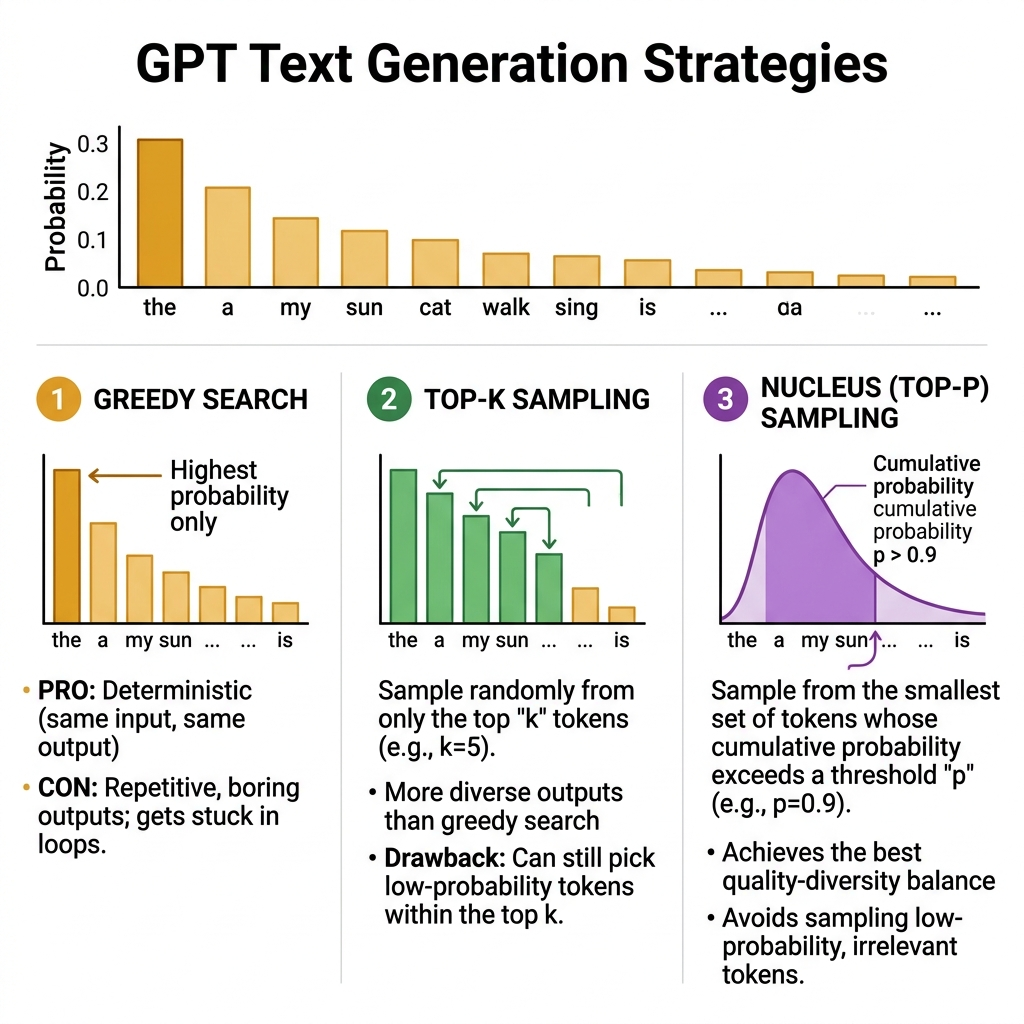

*Figure 2: GPT Text Generation Strategies — Greedy, Top-K Sampling, and Nucleus (Top-P) Sampling compared*



## 4. The Autoregressive Generation Pipeline

GPT generates text **one token at a time**, feeding each generated token back as input for the next step:

```
Step 1: Input: [The]              → Output: distribution over vocab → sample 'cat'
Step 2: Input: [The, cat]         → Output: distribution over vocab → sample 'sat'
Step 3: Input: [The, cat, sat]    → Output: distribution over vocab → sample 'on'
...continues until [EOS] token or max length reached
```

### Decoding Strategies

How you **sample** from the output distribution has enormous impact on generation quality:

**1. Greedy Decoding**
- Always pick the single highest-probability token
- Problem: deterministic and repetitive. The model gets trapped in loops like "the the the the"

**2. Top-K Sampling**
- Sample randomly from only the **top K** most probable tokens
- K=50 is a common choice. Prevents sampling from tiny-probability tokens
- Problem: if the probability distribution is broad (many valid next words), top-K might cut off valid options; if narrow, it lets in too many bad options

**3. Nucleus Sampling (Top-P)**
- Sample from the smallest set of tokens whose **cumulative probability ≥ P** (typically P=0.9)
- Adapts dynamically to the distribution — narrow dists use few tokens, broad dists use many
- Generally produces the best text quality

**4. Temperature**
- Divides all logits by temperature T before softmax
- T < 1.0 → sharper distribution (more confident, less diverse)
- T > 1.0 → flatter distribution (more random, more creative)
- T = 0 → equivalent to greedy

---

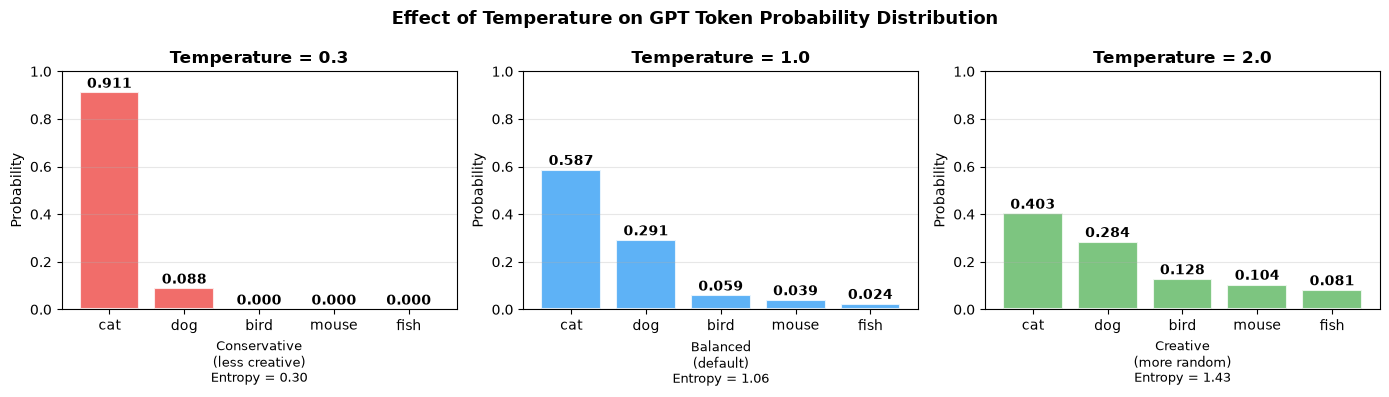

Low temperature → concentrated distribution → safe but repetitive.
High temperature → flat distribution → diverse but potentially incoherent.


In [3]:
# Visualize probability distributions under different temperatures
import numpy as np
import matplotlib.pyplot as plt

# Simulated next-token logits (5 most likely tokens for demo)
token_labels = ['cat', 'dog', 'bird', 'mouse', 'fish']
logits = np.array([3.5, 2.8, 1.2, 0.8, 0.3])
temperatures = [0.3, 1.0, 2.0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#EF5350', '#42A5F5', '#66BB6A']

for ax, temp, col in zip(axes, temperatures, colors):
    adjusted_logits = logits / temp
    probs = np.exp(adjusted_logits) / np.exp(adjusted_logits).sum()
    bars = ax.bar(token_labels, probs, color=col, alpha=0.85, edgecolor='white', lw=1.5)
    ax.set_title(f'Temperature = {temp}', fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Probability')
    for bar, prob in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{prob:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    # Entropy label
    entropy = -np.sum(probs * np.log(probs + 1e-9))
    label_map = {0.3: 'Conservative\n(less creative)', 1.0: 'Balanced\n(default)', 2.0: 'Creative\n(more random)'}
    ax.set_xlabel(f'{label_map[temp]}\nEntropy = {entropy:.2f}', fontsize=9)

plt.suptitle('Effect of Temperature on GPT Token Probability Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_temperature_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print('Low temperature → concentrated distribution → safe but repetitive.')
print('High temperature → flat distribution → diverse but potentially incoherent.')

## 5. Hands-on: GPT-2 Text Generation

Let's generate text with GPT-2 using different sampling strategies and compare the outputs.

---

In [4]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

tokenizer = GPT2Tokenizer.from_pretrained('./data/gpt2')
tokenizer.pad_token = tokenizer.eos_token
lm_model = GPT2LMHeadModel.from_pretrained('./data/gpt2')
lm_model.eval()

prompt = 'Artificial intelligence will transform the future of medicine by'
inputs = tokenizer(prompt, return_tensors='pt')
input_ids = inputs['input_ids']

strategies = [
    ('Greedy Decoding',
     dict(max_new_tokens=60, do_sample=False)),
    ('Top-K Sampling (k=50)',
     dict(max_new_tokens=60, do_sample=True, top_k=50, temperature=1.0)),
    ('Nucleus Sampling (p=0.92)',
     dict(max_new_tokens=60, do_sample=True, top_p=0.92, temperature=0.9)),
    ('Temperature=0.5 (Conservative)',
     dict(max_new_tokens=60, do_sample=True, top_p=0.95, temperature=0.5)),
]

print(f'Prompt: "{prompt}"\n')
print('=' * 72)

for name, kwargs in strategies:
    with torch.no_grad():
        output_ids = lm_model.generate(
            input_ids, pad_token_id=tokenizer.eos_token_id,
            **kwargs
        )
    generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # Strip the prompt from the output
    continuation = generated[len(prompt):].strip()
    print(f'\n[{name}]')
    print(f'{continuation}')
    print('-' * 72)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Prompt: "Artificial intelligence will transform the future of medicine by"




[Greedy Decoding]
providing a new way to diagnose, treat, and prevent diseases.

The new technology will be used to develop new treatments for diseases such as cancer, heart disease, diabetes, and Alzheimer's disease.

The technology will also be used to develop new treatments for diseases such as cancer, heart
------------------------------------------------------------------------



[Top-K Sampling (k=50)]
leveraging powerful data on human behavior and the capacity for natural selection to modify its processes and outcomes.

The researchers developed a protocol that has previously been used in experiments with primates. They have shown how they can successfully change their behavior and alter their genetic background by developing a genetic algorithm with a different genetic
------------------------------------------------------------------------



[Nucleus Sampling (p=0.92)]
making them easier to implement.

In an interview with Newsweek on Wednesday, Thomas E. Smith, chief technologist at Google, said that the future of medicine is in the hands of humans who can better understand and control diseases and disease therapies. Smith said that if AI is a part of that
------------------------------------------------------------------------



[Temperature=0.5 (Conservative)]
creating new treatments for diseases like cancer, heart disease and diabetes.

"It's a great moment for us," said Dr. Michael R. Hurd, chief scientist of the Center for Neural Engineering at the University of California, Berkeley. "We're seeing a lot of advances in artificial intelligence
------------------------------------------------------------------------


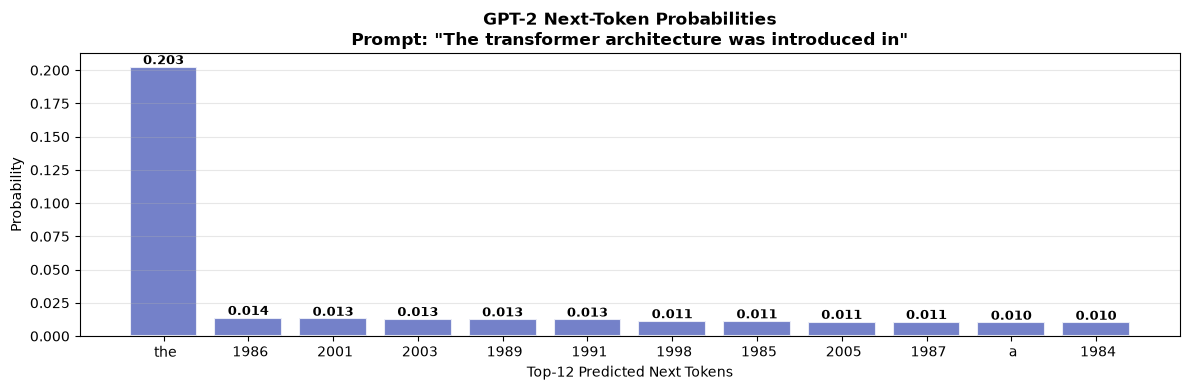

Most likely next token: " the" (prob=0.203)
GPT-2 has learned that transformers were introduced "in 2017" from its training data!


In [5]:
# Token-by-token probability trace for one generation step
import torch
import matplotlib.pyplot as plt
import numpy as np

prompt_short = 'The transformer architecture was introduced in'
inputs = tokenizer(prompt_short, return_tensors='pt')

with torch.no_grad():
    outputs = lm_model(**inputs)
    logits = outputs.logits[0, -1, :]  # logits for NEXT token prediction

probs = torch.softmax(logits, dim=-1)
top_k = 12
top_probs, top_ids = torch.topk(probs, top_k)
top_tokens = [tokenizer.decode([idx.item()]) for idx in top_ids]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(top_tokens, top_probs.numpy(), color='#5C6BC0', alpha=0.85, edgecolor='white', lw=1.5)
ax.set_title(f'GPT-2 Next-Token Probabilities\nPrompt: "{prompt_short}"',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Top-12 Predicted Next Tokens')
ax.set_ylabel('Probability')
ax.grid(axis='y', alpha=0.3)
for bar, prob in zip(bars, top_probs.numpy()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{prob:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_gpt2_token_probs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Most likely next token: "{top_tokens[0]}" (prob={top_probs[0]:.3f})')
print(f'GPT-2 has learned that transformers were introduced "in 2017" from its training data!')

## 6. GPT-2 Architectural Refinements Over the Original Transformer

GPT-2 makes several specific improvements to the vanilla Transformer Decoder:

| Component | Original Transformer | GPT-2 |
|---|---|---|
| **Layer Normalization** | Post-LN (after attention/FFN) | **Pre-LN** (before attention/FFN) — more stable gradients |
| **Weight Initialization** | Xavier/Glorot | Scaled initialization: residual stream weighted by `1/sqrt(N)` where N=num_layers |
| **Position Encoding** | Fixed sinusoidal | **Learned** absolute position embeddings |
| **Cross-attention** | Yes (Encoder-Decoder) | **Removed** — GPT-2 is decoder-only, no source sequence |
| **Vocabulary** | Task-specific | **BPE** with 50,257 tokens — handles any text including code |

### Pre-LN vs Post-LN: Why It Matters

Pre-LayerNorm (Layer Norm applied BEFORE the sub-layer):
```
Post-LN: x → [Attention] → Add → [LayerNorm] → [FFN] → Add → [LayerNorm]
Pre-LN:  x → [LayerNorm] → [Attention] → Add → [LayerNorm] → [FFN] → Add
```
Pre-LN creates a direct gradient path through residual connections, making it significantly more stable when training very deep networks (40+ layers in GPT-3).

---

## 7. Summary: BERT vs. GPT — The Architectural Fork

```
         Transformer ("Attention Is All You Need", 2017)
                    /                    \
          Encoder-Only               Decoder-Only
         (Bidirectional)           (Unidirectional/Causal)
               |                          |
             BERT                        GPT
         (Google, 2018)              (OpenAI, 2018)
               |                          |
         RoBERTa, ALBERT           GPT-2, GPT-3, GPT-4
         DistilBERT, DeBERTa       LLaMA, Mistral, Claude
```

- **BERT and its family** dominate **understanding tasks**: text classification, NER, question answering, sentence similarity
- **GPT and its family** dominate **generation tasks**: text completion, dialogue, code generation, creative writing
- Modern models (GPT-4, Claude, Gemini) are all GPT-style Decoder-only architectures scaled to hundreds of billions of parameters

### What's Next
Notebook 7 explores how GPT scaled from 117M parameters (GPT-1) to 175B (GPT-3) and the emergent capabilities that appeared along the way — in-context learning, chain-of-thought reasoning, and the RLHF pipeline that created ChatGPT.

---
*Phase 8, Notebook 6 of 10 — NLP From Scratch: Foundation to Advanced*